In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, deconvolve, convolve

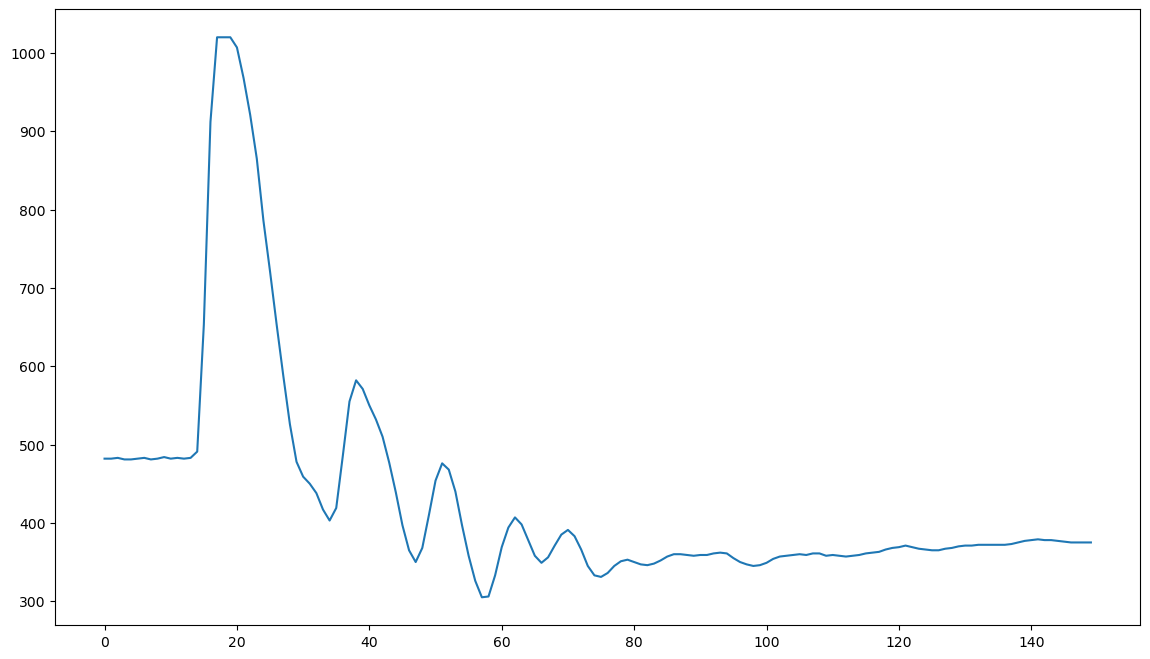

In [408]:
df_iu = pd.read_csv('/home/pico/projects/piezo_data_impulse_500hz.csv')
df_iu['sum'] = df_iu['top'] + df_iu['bottom'] + df_iu['left'] + df_iu['right']

fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
impulse = df_iu['sum'].values[1600:1750]

ax.plot(impulse)



In [400]:
df = pd.read_csv('/home/pico/projects/piezo_data_20250423_002954.csv')
df.head()

,timestamp,top,bottom,left,right,force
0,9996,120,120,120,121,135
1,9998,120,120,121,120,134
2,10000,120,121,121,121,135
3,10002,120,121,121,120,135
4,10004,120,121,120,120,134


In [401]:
df['timestamp'] = df['timestamp'] - df['timestamp'][0]
df.head()

,timestamp,top,bottom,left,right,force
0,0,120,120,120,121,135
1,2,120,120,121,120,134
2,4,120,121,121,121,135
3,6,120,121,121,120,135
4,8,120,121,120,120,134


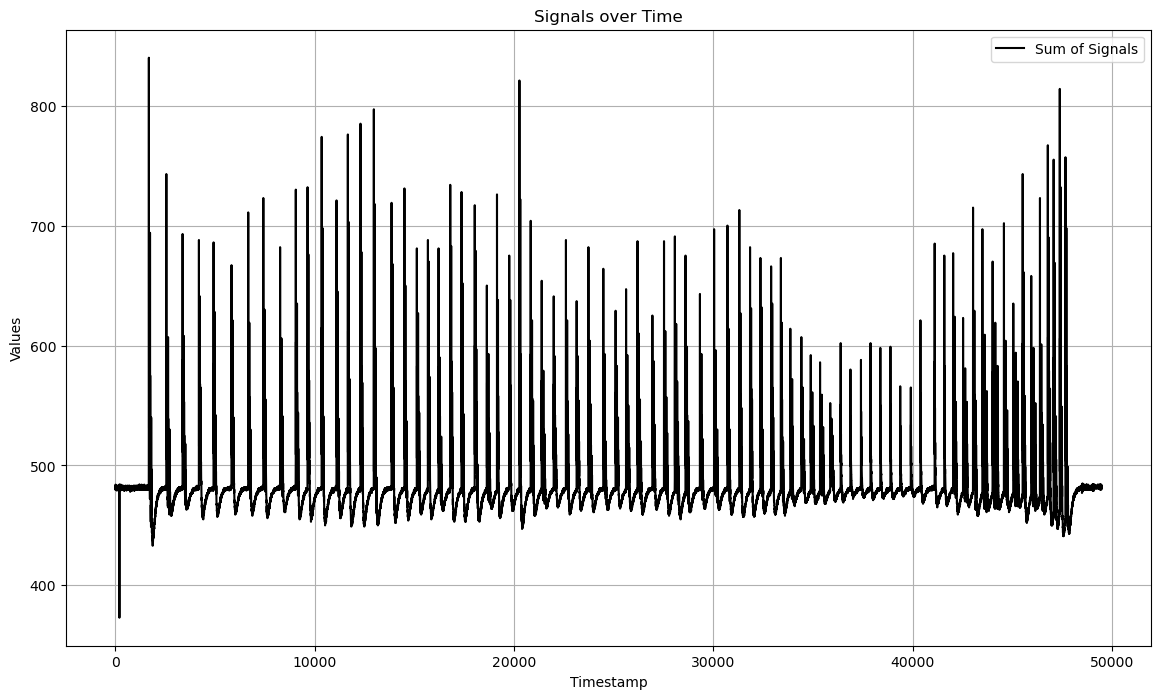

In [443]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed

df_subset = df.iloc[:]#[5100:5300]  # Select the first n rows for plotting

# sum all the signals
df_subset['sum'] = df_subset[['top', 'bottom', 'left', 'right']].sum(axis=1)

# Plot the sum of all signals
ax.plot(df_subset['sum'], label='Sum of Signals', color='black')

# Plot each signal on the same axes
#ax.plot(df_subset['timestamp'], df_subset['top'], label='Top', color='blue')
#ax.plot(df_subset['timestamp'], df_subset['bottom'], label='Bottom', color='orange')
#ax.plot(df_subset['timestamp'], df_subset['left'], label='Left', color='green')
#ax.plot(df_subset['timestamp'], df_subset['right'], label='Right', color='red')
#ax.plot(df_subset['timestamp'], df_subset['force'], label='Force', color='purple')

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Values')
ax.set_title('Signals over Time')
ax.legend()  # Show legend
ax.grid()  # Add grid for better readability

# Show the plot
#plt.tight_layout()  # Adjust layout to make room for the legend

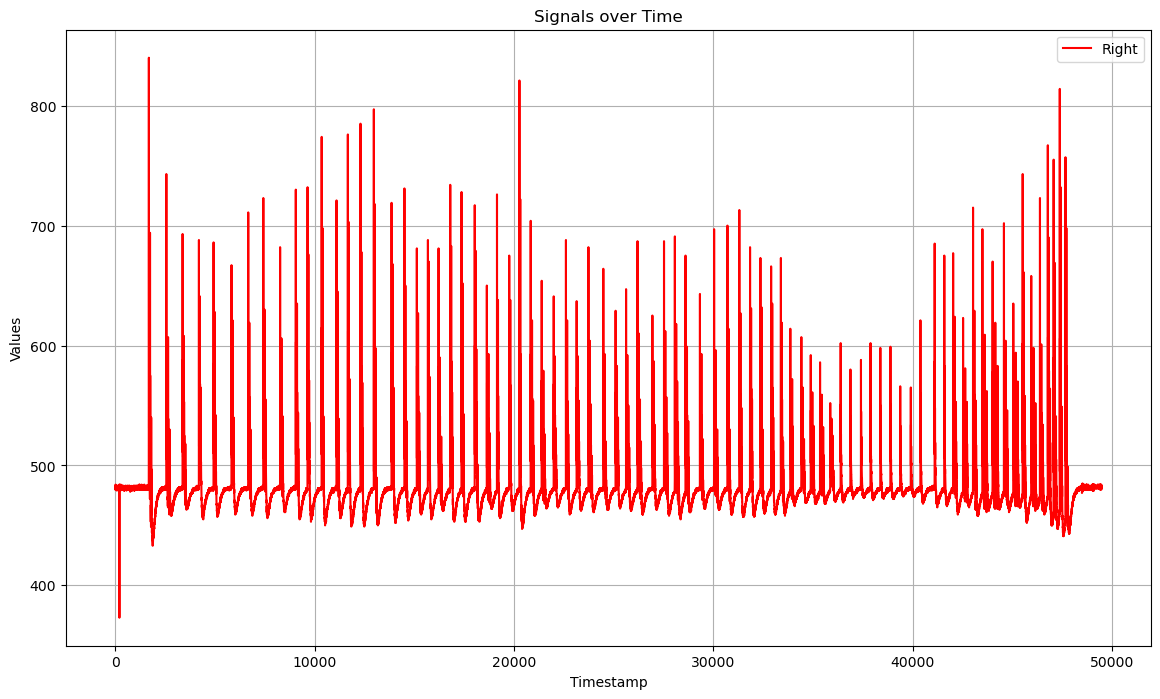

In [427]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed

#df_subset = df.iloc[1080:1100]  # Select the first n rows for plotting

# Plot each signal on the same axes
#ax.plot(df_subset['timestamp'], df_subset['top'], label='Top', color='blue')
#ax.plot(df_subset['timestamp'], df_subset['bottom'], label='Bottom', color='orange')
#ax.plot(df_subset['timestamp'], df_subset['left'], label='Left', color='green')
#ax.plot(df_subset['timestamp'], df_subset['right'], label='Right', color='red')
#ax.plot(df_subset['timestamp'], df_subset['force'], label='Force', color='purple')
ax.plot(df_subset['sum'], label='Right', color='red')
# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Values')
ax.set_title('Signals over Time')
ax.legend()  # Show legend
ax.grid()  # Add grid for better readability

# Show the plot
#plt.tight_layout()  # Adjust layout to make room for the legend

In [259]:
def butter_highpass(cutoff, fs, order=5):
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq  # Normalized cutoff frequency
    b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Filter coefficients
    return b, a

def highpass_filter(data, cutoff, fs, order=5):
    b, a = butter_highpass(cutoff, fs, order=order)  # Get filter coefficients
    y = lfilter(b, a, data)  # Apply the filter
    return y

/tmp/ipykernel_234778/327499135.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['sum'] = df_subset['sum'] - 480


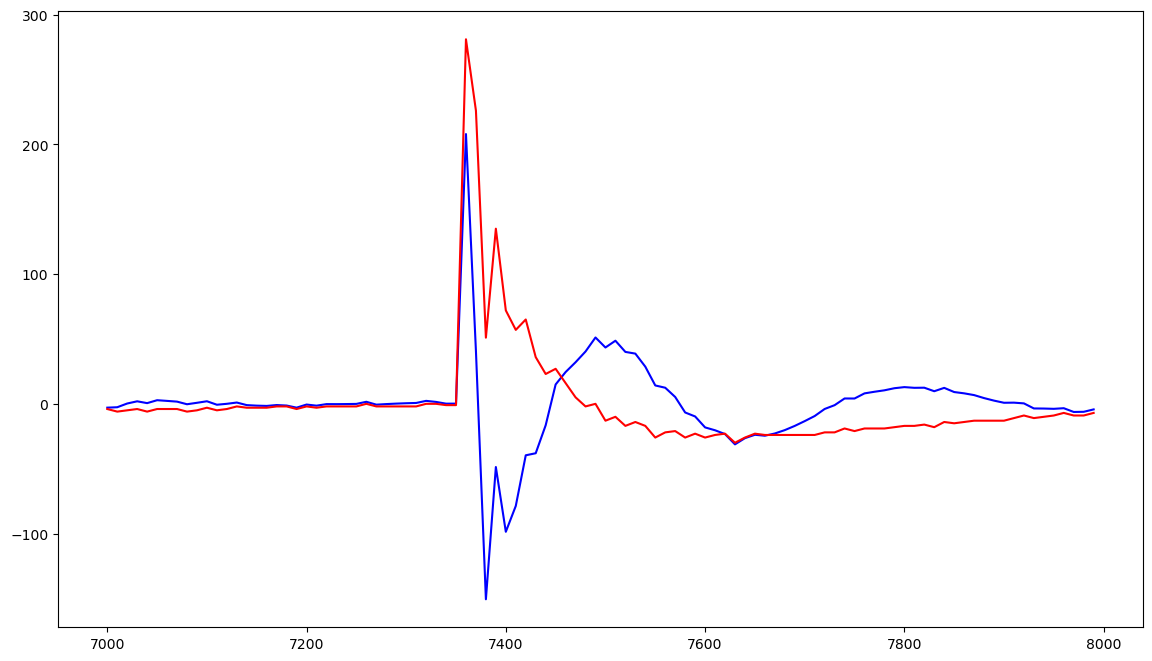

In [260]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed

#sum of all signals
#df_subset['sum'] = df_subset['top'] + df_subset['bottom'] + df_subset['left'] + df_subset['right']
#df_subset['sum'] = (df_subset['sum'] / 4) - 128  # Normalize by dividing by the number of signals
df_subset['sum'] = df_subset['sum'] - 480

# Plot each signal on the same axes
l = 'sum'
ax.plot(df_subset['timestamp'], highpass_filter(df_subset[l], 3, 100), label='Top', color='blue')
ax.plot(df_subset['timestamp'], df_subset[l], label='Top', color='red')

(0.0, 50.0)

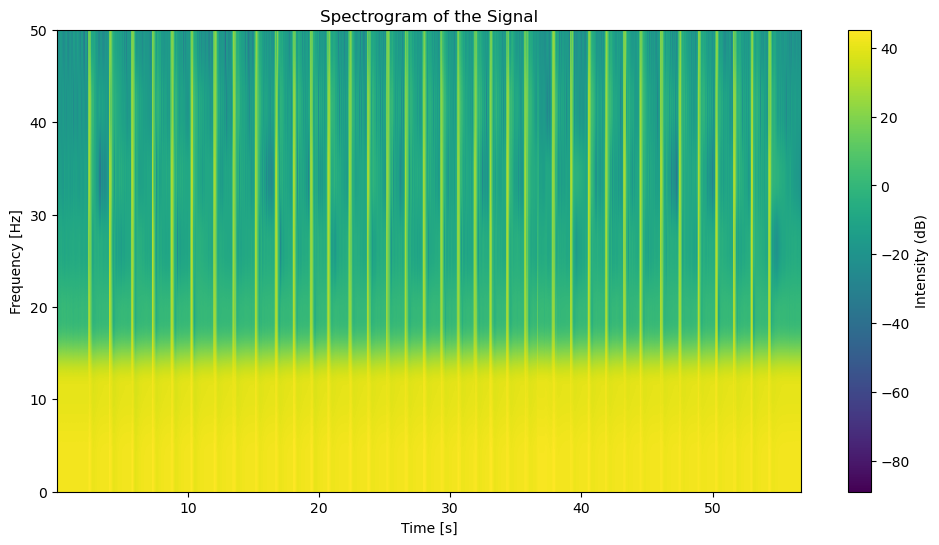

In [342]:
# Plot the spectrogram
plt.figure(figsize=(12, 6))
plt.specgram(df_subset['sum'], NFFT=64, Fs=500, Fc=0, noverlap=32, cmap='viridis', sides='default', mode='default')
plt.colorbar(label='Intensity (dB)')
plt.title('Spectrogram of the Signal')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
#plt.xlim(0, 1)  # Limit x-axis to the duration of the signal
plt.ylim(0, 50)  # Limit y-axis to 500 Hz for better visibility
#plt.grid()

In [467]:
#signal = (df_subset['sum'].values.astype(float)/4)-120
signal = df_subset['sum'].values.astype(float) - 480
# convert impulse to float
impulse = (impulse.astype(float)/4)-120
#plt.figure(figsize=(12, 6))



Data range: -1.3626229193095837e+308 to 1.7976931348623157e+308
[ 5.5   0.5  -2.75 ...  0.    0.    0.  ]


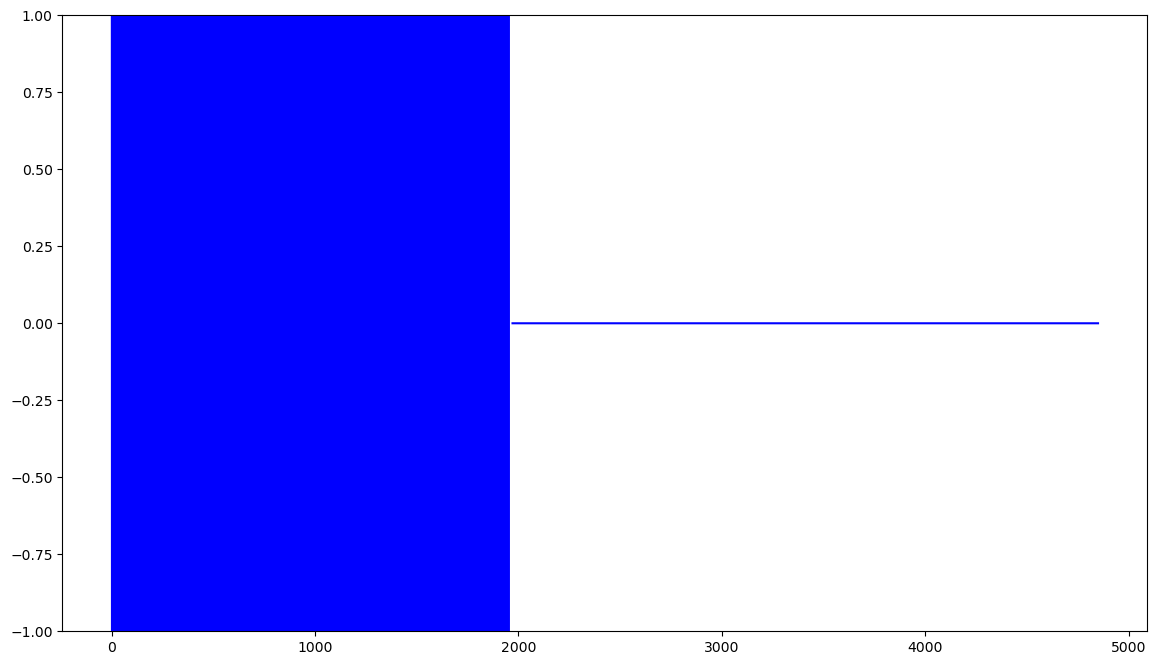

In [410]:
quotient, remainder = deconvolve(signal, impulse)
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
# replace nans with 0
quotient = np.nan_to_num(quotient)
#plt.plot(quotient, label='Quotient', color='blue')
plt.ylim(-1, 1)  # Limit y-axis to 500 Hz for better visibility
ax.plot(quotient, label='Quotient', color='blue')
vmin, vmax = np.min(quotient), np.max(quotient)
print(f"Data range: {vmin} to {vmax}")
df.head()
print(quotient)

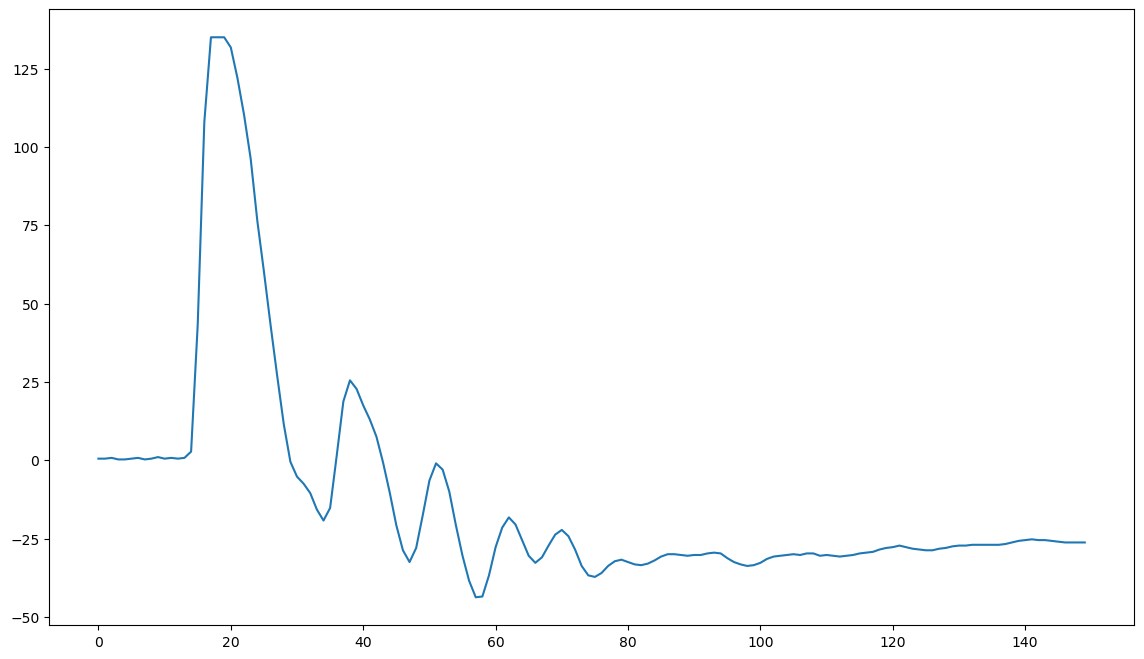

In [411]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
ax.plot(impulse)

In [354]:
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

In [412]:
filtered_signal = lowpass_filter(signal, 20, 500, order=6)
#filtered_signal = highpass_filter(filtered_signal, 1, 100)
#filtered_signal = np.diff(filtered_signal)

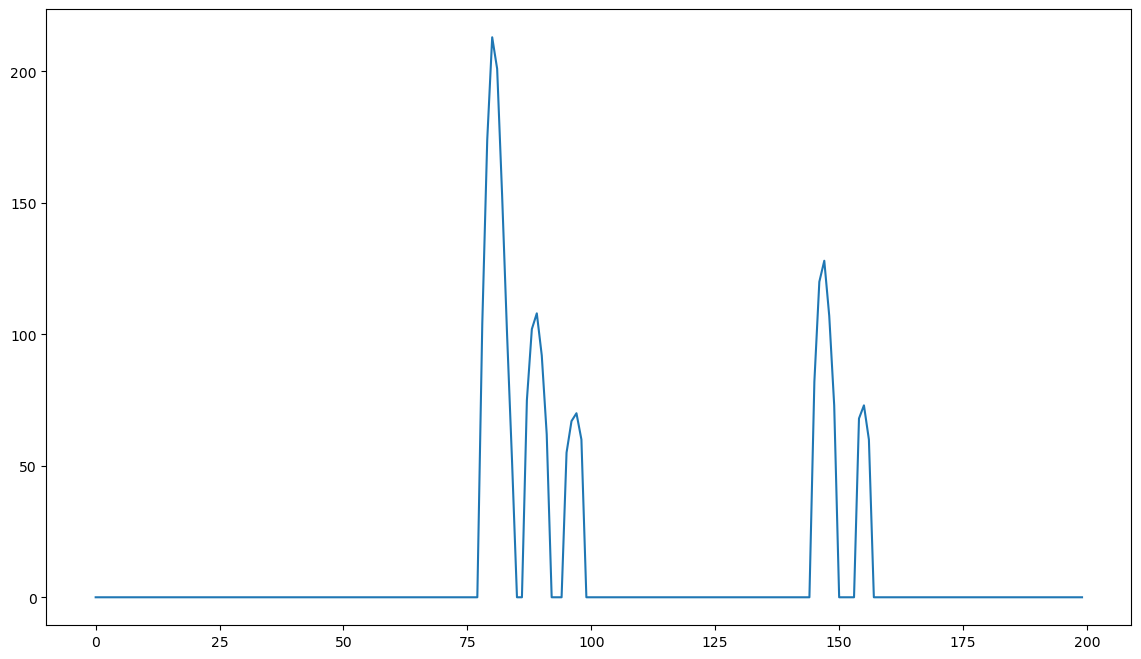

In [449]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
#ax.plot(filtered_signal, color='blue')
s = signal.copy()
s[s < 50] = 0
ax.plot(s[3300:3500])
#ax.plot(np.diff(s[3300:3500]))


In [439]:
1/2e-3

500.0

In [471]:
def detect_peaks(signal, threshold=0):
    peaks = []
    n = len(signal)

    for i in range(1, n - 1):  # Avoid the first and last points
        # Check if the current point is greater than its neighbors
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            # Check if the peak is above the threshold
            if signal[i] > threshold:
                peaks.append(signal[i])
            else:
                peaks.append(0)
        else:
            peaks.append(0)

    return peaks


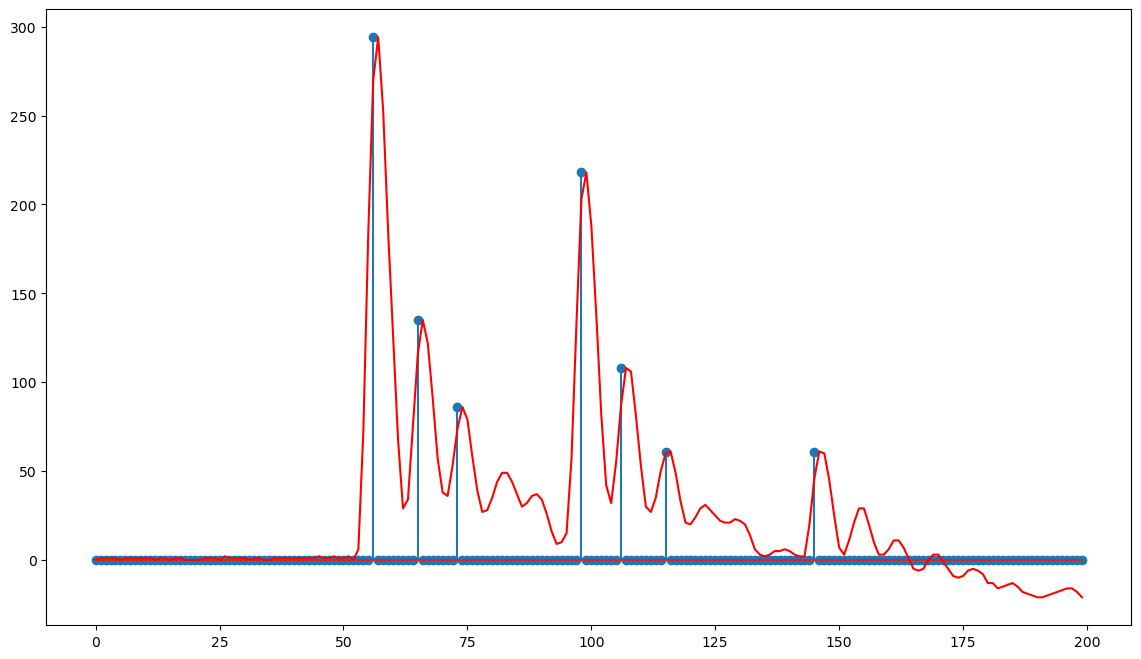

In [481]:
peaks = detect_peaks(signal, threshold=50)

fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
ax.stem(peaks[10300:10500])
ax.plot(signal[10300:10500], color='red')